# Datasets

Combine real (dair-ai/emotion) and synthetic (ELSA) emotion datasets into a single dataframe with unified 'text', 'label', 'type' columns.

In [ ]:
import os
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split

In [ ]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU")

True Tesla T4


In [ ]:
real_ds = load_dataset("dair-ai/emotion", "split")
# IF 'split' config produced an error:
# real_ds = load_dataset("dair-ai/emotion")

real_df = real_ds["train"].to_pandas()
real_df

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,1
15998,i feel like this was such a rude comment and i...,3


In [ ]:
synth_ds = load_dataset("joyspace-ai/ELSA-Emotion-and-Language-Style-Alignment-Dataset")
synth_df = synth_ds["train"].to_pandas()
synth_df.head()

README.md:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

elsa_dataset.csv:   0%|          | 0.00/6.24M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10434 [00:00<?, ? examples/s]

,id,dair_ai_id,original_text,original_emotion,emotion_type,conversational,poetic,formal,narrative
0,1,1,i feel sorry about you because your point of v...,sadness,sadness,It's tough to see how your views have been sha...,"A heart heavy with sorrow, for your thoughts a...",It is regrettable that your perspective appear...,"I can't help but feel a deep sadness for you, ..."
1,2,1,i feel sorry about you because your point of v...,sadness,grief,I really feel for you; it’s a shame how those ...,"In the shadow of loss, I mourn the clarity of ...",It is disheartening to witness the impact of t...,"As I reflect on your situation, a wave of grie..."
2,3,1,i feel sorry about you because your point of v...,sadness,remorse,I wish things were different for you; it’s sad...,"With a heavy heart, I lament the influence of ...",There is a sense of regret regarding the educa...,"As I think about your beliefs, I feel a pang o..."
3,4,2,i feel like he s watching quietly because he s...,sadness,sadness,"It seems like he's just sitting there, accepti...","In silent observation, he sits, burdened by th...",He appears to be in a state of quiet observati...,"He watched from the shadows, a resigned figure..."
4,5,2,i feel like he s watching quietly because he s...,sadness,grief,"You can tell he's just there, quietly mourning...","He lingers in the stillness, grieving the ephe...",His demeanor suggests a profound sense of grie...,"In the quiet corners of his mind, he grieved, ..."


In [ ]:
print("dair-ai/emotion columns:", real_df.columns.tolist())
print("ELSA columns:", synth_df.columns.tolist())

dair-ai/emotion columns: ['text', 'label']
ELSA columns: ['id', 'dair_ai_id', 'original_text', 'original_emotion', 'emotion_type', 'conversational', 'poetic', 'formal', 'narrative']


### Add dataset type

In [ ]:
real_df["type"] = "real"
synth_df["type"] = "synthetic"

real_df.head()

,text,label,type
0,i didnt feel humiliated,0,real
1,i can go from feeling so hopeless to so damned...,0,real
2,im grabbing a minute to post i feel greedy wrong,3,real
3,i am ever feeling nostalgic about the fireplac...,2,real
4,i am feeling grouchy,3,real


In [ ]:
synth_df.head()

,id,dair_ai_id,original_text,original_emotion,emotion_type,conversational,poetic,formal,narrative,type
0,1,1,i feel sorry about you because your point of v...,sadness,sadness,It's tough to see how your views have been sha...,"A heart heavy with sorrow, for your thoughts a...",It is regrettable that your perspective appear...,"I can't help but feel a deep sadness for you, ...",synthetic
1,2,1,i feel sorry about you because your point of v...,sadness,grief,I really feel for you; it’s a shame how those ...,"In the shadow of loss, I mourn the clarity of ...",It is disheartening to witness the impact of t...,"As I reflect on your situation, a wave of grie...",synthetic
2,3,1,i feel sorry about you because your point of v...,sadness,remorse,I wish things were different for you; it’s sad...,"With a heavy heart, I lament the influence of ...",There is a sense of regret regarding the educa...,"As I think about your beliefs, I feel a pang o...",synthetic
3,4,2,i feel like he s watching quietly because he s...,sadness,sadness,"It seems like he's just sitting there, accepti...","In silent observation, he sits, burdened by th...",He appears to be in a state of quiet observati...,"He watched from the shadows, a resigned figure...",synthetic
4,5,2,i feel like he s watching quietly because he s...,sadness,grief,"You can tell he's just there, quietly mourning...","He lingers in the stillness, grieving the ephe...",His demeanor suggests a profound sense of grie...,"In the quiet corners of his mind, he grieved, ...",synthetic


## Transform datasets
ELSA:
Keep only conversational, original_emotion, and type. Rename conversational -> text, original_emotion -> label for further dataset combination.
We choose "conversational" because it mimics the real data the most.

dair-ai:
Map numeric labels to emotion names based on the information from dataset page.

In [ ]:
expected_elsa_cols = {"conversational", "original_emotion"}
missing = expected_elsa_cols - set(synth_df.columns)
if missing:
    raise ValueError(
        f"ELSA is missing expected column(s): {missing}. "
        f"Actual columns are: {synth_df.columns.tolist()}. "
        f"Update the column names above to match."
    )

synth_df = synth_df[["conversational", "original_emotion", "type"]].rename(
    columns={"conversational": "text", "original_emotion": "label"}
)

In [ ]:
synth_df

,text,label,type
0,It's tough to see how your views have been sha...,sadness,synthetic
1,I really feel for you; it’s a shame how those ...,sadness,synthetic
2,I wish things were different for you; it’s sad...,sadness,synthetic
3,"It seems like he's just sitting there, accepti...",sadness,synthetic
4,"You can tell he's just there, quietly mourning...",sadness,synthetic
...,...,...,...
10429,"I really enjoy their music, but it feels like ...",joy,synthetic
10430,"I totally love their music, but it feels like ...",joy,synthetic
10431,"I really admire their music, but I feel they h...",joy,synthetic
10432,"I’m so thankful for their music, but I feel li...",joy,synthetic


In [ ]:
label_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise",
}

real_df["label"] = real_df["label"].map(label_map)
real_df = real_df[["text", "label", "type"]]

real_df

,text,label,type
0,i didnt feel humiliated,sadness,real
1,i can go from feeling so hopeless to so damned...,sadness,real
2,im grabbing a minute to post i feel greedy wrong,anger,real
3,i am ever feeling nostalgic about the fireplac...,love,real
4,i am feeling grouchy,anger,real
...,...,...,...
15995,i just had a very brief time in the beanbag an...,sadness,real
15996,i am now turning and i feel pathetic that i am...,sadness,real
15997,i feel strong and good overall,joy,real
15998,i feel like this was such a rude comment and i...,anger,real


In [ ]:
# dair-ai/emotion contains a small number of duplicate sentences;
# dedup before any splitting so no duplicate can land in two different splits
before = len(real_df)
real_df = real_df.drop_duplicates(subset=["text"]).reset_index(drop=True)
print(f"Removed {before - len(real_df)} duplicate texts from real_df")

real_df

Removed 31 duplicate texts from real_df


,text,label,type
0,i didnt feel humiliated,sadness,real
1,i can go from feeling so hopeless to so damned...,sadness,real
2,im grabbing a minute to post i feel greedy wrong,anger,real
3,i am ever feeling nostalgic about the fireplac...,love,real
4,i am feeling grouchy,anger,real
...,...,...,...
15964,i just had a very brief time in the beanbag an...,sadness,real
15965,i am now turning and i feel pathetic that i am...,sadness,real
15966,i feel strong and good overall,joy,real
15967,i feel like this was such a rude comment and i...,anger,real


In [ ]:
print("Real label proportions:")
print(real_df["label"].value_counts(normalize=True))

print("\nSynthetic label counts (raw):")
print(synth_df["label"].value_counts(normalize=True))

Real label proportions:
label
joy         0.335024
sadness     0.292066
anger       0.134949
fear        0.121047
love        0.081345
surprise    0.035569
Name: proportion, dtype: float64

Synthetic label counts (raw):
label
joy         0.263082
anger       0.210753
sadness     0.158137
love        0.156987
fear        0.105616
surprise    0.105425
Name: proportion, dtype: float64


In [ ]:
# evaluation is done on real-world data only
real_train_pool, real_holdout = train_test_split(
    real_df,
    test_size=4000,
    random_state=42,
    shuffle=True,
    stratify=real_df["label"]
)

real_val, real_test = train_test_split(
    real_holdout,
    test_size=0.5,
    random_state=42,
    shuffle=True,
    stratify=real_holdout["label"]
)

real_train_pool = real_train_pool.reset_index(drop=True)
real_val = real_val.reset_index(drop=True)
real_test = real_test.reset_index(drop=True)

print("Real train pool:", len(real_train_pool))
print("Real validation:", len(real_val))
print("Real test:", len(real_test))

Real train pool: 11969
Real validation: 2000
Real test: 2000


In [ ]:
print("train_pool ∩ val:", len(set(real_train_pool["text"]) & set(real_val["text"])))
print("train_pool ∩ test:", len(set(real_train_pool["text"]) & set(real_test["text"])))

train_pool ∩ val: 0
train_pool ∩ test: 0


In [ ]:
holdout_texts = set(real_val["text"]).union(set(real_test["text"]))

synth_df_clean = synth_df[
    ~synth_df["text"].isin(holdout_texts)
].reset_index(drop=True)

print("Synthetic before cleaning:", len(synth_df))
print("Synthetic after removing val/test duplicates:", len(synth_df_clean))
print("Removed:", len(synth_df) - len(synth_df_clean))

Synthetic before cleaning: 10434
Synthetic after removing val/test duplicates: 10434
Removed: 0


# Combining datasets

In [ ]:
ratios = [1.0, 0.75, 0.5, 0.25, 0.0]

In [ ]:
mixed_datasets = {}
TOTAL_TRAIN_SIZE = 10_000


for ratio in ratios:
    n_real = int(TOTAL_TRAIN_SIZE * ratio)
    n_synth = TOTAL_TRAIN_SIZE - n_real

    if n_real > 0:
        real_sample = real_train_pool.sample(
            n=n_real,
            random_state=42,
            replace=False
        )
    else:
        real_sample = pd.DataFrame(columns=real_train_pool.columns)

    if n_synth > 0:
        synth_sample = synth_df_clean.sample(
            n=n_synth,
            random_state=42,
            replace=False
        )
    else:
        synth_sample = pd.DataFrame(columns=synth_df_clean.columns)

    mixed_df = pd.concat([real_sample, synth_sample], ignore_index=True)

    # mixing real and synthetic in train
    mixed_df = mixed_df.sample(frac=1, random_state=42).reset_index(drop=True)


    name = f"real_{int(ratio * 100)}_synth_{int((1-ratio) * 100)}"
    mixed_datasets[name] = mixed_df

    print("=" * 40)
    print(name)
    print("Size:", len(mixed_df))
    print("Source distribution:")
    print(mixed_df["type"].value_counts())
    print("Label distribution:")
    print(mixed_df["label"].value_counts())

real_100_synth_0
Size: 10000
Source distribution:
type
real    10000
Name: count, dtype: int64
Label distribution:
label
joy         3359
sadness     2920
anger       1322
fear        1218
love         830
surprise     351
Name: count, dtype: int64
real_75_synth_25
Size: 10000
Source distribution:
type
real         7500
synthetic    2500
Name: count, dtype: int64
Label distribution:
label
joy         3187
sadness     2589
anger       1484
fear        1223
love        1012
surprise     505
Name: count, dtype: int64
real_50_synth_50
Size: 10000
Source distribution:
type
synthetic    5000
real         5000
Name: count, dtype: int64
Label distribution:
label
joy         3008
sadness     2328
anger       1685
love        1176
fear        1123
surprise     680
Name: count, dtype: int64
real_25_synth_75
Size: 10000
Source distribution:
type
synthetic    7500
real         2500
Name: count, dtype: int64
Label distribution:
label
joy         2798
sadness     1941
anger       1899
love        138

In [ ]:
df_100_0 = mixed_datasets["real_100_synth_0"]
df_75_25 = mixed_datasets["real_75_synth_25"]
df_50_50 = mixed_datasets["real_50_synth_50"]
df_25_75 = mixed_datasets["real_25_synth_75"]
df_0_100 = mixed_datasets["real_0_synth_100"]

In [ ]:
combined_df = pd.concat([real_df, synth_df], ignore_index=True)
combined_df.sample(10)

,text,label,type
20283,"It feels like I’m sitting here, lost between t...",sadness,synthetic
4198,i feel like im being taken advantage of and on...,anger,real
24785,It's funny how I feel like I'm missing my diam...,joy,synthetic
7453,ive waited my whole life to feel this blessed ...,love,real
25619,I’m having a blast being myself! I want to get...,joy,synthetic
8208,i am feeling grumpy i put this on,anger,real
25357,I can't believe how freeing it feels to move o...,joy,synthetic
7246,i feel like i lack any real knowledge or skill...,joy,real
14463,i feel pretty passionate about is helping people,joy,real
9084,i must say im not feeling very optimistic,joy,real


In [ ]:
print("Row counts by type:")
print(combined_df["type"].value_counts())

Row counts by type:
type
real         15969
synthetic    10434
Name: count, dtype: int64


In [ ]:
print("Row counts by type and label:")
print(combined_df.groupby(["type", "label"]).size())

Row counts by type and label:
type       label   
real       anger       2155
           fear        1933
           joy         5350
           love        1299
           sadness     4664
           surprise     568
synthetic  anger       2199
           fear        1102
           joy         2745
           love        1638
           sadness     1650
           surprise    1100
dtype: int64


In [ ]:
print(f"Total combined rows: {len(combined_df)}")

Total combined rows: 26403


Save the csv:

In [ ]:
combined_df.to_csv("combined_dataset.csv", index=False)
print("Saved to combined_dataset.csv")

Saved to combined_dataset.csv


# Testing dataset comparability



In [ ]:
print("Real labels:", sorted(real_df["label"].unique()))
print("Synthetic labels:", sorted(synth_df["label"].unique()))

Real labels: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
Synthetic labels: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']


In [ ]:
for name, df in mixed_datasets.items():
    print(name, "nulls:", df.isnull().sum().sum(), "empty text:", (df["text"].str.strip() == "").sum())

real_100_synth_0 nulls: 0 empty text: 0
real_75_synth_25 nulls: 0 empty text: 0
real_50_synth_50 nulls: 0 empty text: 0
real_25_synth_75 nulls: 0 empty text: 0
real_0_synth_100 nulls: 0 empty text: 0


In [ ]:
# ELSA was built by taking sentences from dair-ai/emotion, so we need to check if there are any dublicates
# diagnostic only
for name, df in mixed_datasets.items():
    print(name, "duplicates:", df.duplicated(subset="text").sum())

real_100_synth_0 duplicates: 0
real_75_synth_25 duplicates: 1
real_50_synth_50 duplicates: 8
real_25_synth_75 duplicates: 13
real_0_synth_100 duplicates: 23


In [ ]:
for name, mixed_df in mixed_datasets.items():
    mixed_df.to_csv(f"{name}.csv", index=False)

In [ ]:
# Text length/style comparability
# ELSA's "conversational" may be a bit too long compared to the real texts. According to these reaults, however, they are not, so everything is fine.
combined_check = pd.concat([real_df.assign(source="real"), synth_df.assign(source="synthetic")])
combined_check["text_len"] = combined_check["text"].str.split().str.len()
combined_check.groupby("source")["text_len"].describe()

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
real,15969.0,19.171708,10.990862,2.0,11.0,17.0,25.0,66.0
synthetic,10434.0,18.956488,7.640942,4.0,13.0,18.0,23.0,69.0


#Preparation

In [ ]:
# Label emotions
label2id = {
    "sadness": 0,
    "joy": 1,
    "love": 2,
    "anger": 3,
    "fear": 4,
    "surprise": 5
}

id2label = {v: k for k, v in label2id.items()}

In [ ]:
val_df = real_val.dropna(subset=["text", "label"]).copy()
test_df = real_test.dropna(subset=["text", "label"]).copy()

val_df = val_df[val_df["text"].str.len() > 2].drop_duplicates(subset=["text"]).reset_index(drop=True)
test_df = test_df[test_df["text"].str.len() > 2].drop_duplicates(subset=["text"]).reset_index(drop=True)

val_df["label_id"] = val_df["label"].map(label2id)
test_df["label_id"] = test_df["label"].map(label2id)

In [ ]:
val_df

,text,label,type,label_id
0,getting a low grade on my physics midterm,anger,real,3
1,i supposed to feel special when you don t even...,joy,real,1
2,i feel we re seeing now is a clash between tho...,fear,real,4
3,i get into conversations and regret them and s...,sadness,real,0
4,i am feeling extremely contented with our deci...,joy,real,1
...,...,...,...,...
1995,i feel eager to do,joy,real,1
1996,i walked away feeling triumphant with my first...,joy,real,1
1997,i feel emotional about how people have treated...,sadness,real,0
1998,i truly felt that when i left friday you were ...,joy,real,1


In [ ]:
test_df

,text,label,type,label_id
0,i feel pretty virtuous about it actually,joy,real,1
1,i bought into what the world had told me would...,fear,real,4
2,i not feeling as melancholy as i was the other...,sadness,real,0
3,i hope you enjoy reading and please feel free ...,joy,real,1
4,i am allowed to feel guilty about neglecting t...,sadness,real,0
...,...,...,...,...
1995,i feel like i cant be brave,joy,real,1
1996,i should feel awful about the nonexistence of ...,sadness,real,0
1997,i am feeling very apprehensive about the futur...,fear,real,4
1998,i was feeling so carefree and wanted to go and...,joy,real,1


In [ ]:
label_map = id2label

labels = [label_map[i] for i in range(6)]

print(labels)

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


## Model


In [ ]:
import pandas as pd
import numpy as np
import re
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [ ]:
# The choice of the model is justified in the article
model_name = "distilroberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted")
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./emotion_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none"
)

In [ ]:
def get_per_emotion_accuracy(trainer, test_dataset, ratio_name):
    import numpy as np
    import pandas as pd
    from sklearn.metrics import confusion_matrix

    predictions = trainer.predict(test_dataset)

    pred_labels = np.argmax(predictions.predictions, axis=-1)
    true_labels = predictions.label_ids

    cm = confusion_matrix(true_labels, pred_labels, labels=list(label_map.keys()))

    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    labels = [label_map[i] for i in label_map.keys()]

    df = pd.DataFrame({
        "ratio": ratio_name,
        "emotion": labels,
        "accuracy": per_class_acc
    })

    return df

The model is re-instantiated fresh each iteration: each ratio condition must start from the same pretrained checkpoint, because otherwise later conditions inherit weights from earlier ones and the comparison is confounded.

In [ ]:
import gc
import torch
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# ------------------ configs -------------------
ratio_keys   = ["real_100_synth_0", "real_75_synth_25", "real_50_synth_50",
                 "real_25_synth_75", "real_0_synth_100"]
#ratio_labels = ["100_0", "75_25", "50_50", "25_75", "0_100"]
ratio_labels = ["100/0", "75/25", "50/50", "25/75", "0/100"]

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

def clean_and_prepare(df, label2id, exclude_texts=None):
    """Same cleaning used to build val_df/test_df above, plus a leakage guard against val/test text"""
    df = df.dropna(subset=["text", "label"]).copy()
    df = df[df["text"].str.len() > 2]
    df = df.drop_duplicates(subset=["text"])
    if exclude_texts is not None:
        df = df[~df["text"].isin(exclude_texts)]
    df["label_id"] = df["label"].map(label2id)
    df = df.dropna(subset=["label_id"])
    df["label_id"] = df["label_id"].astype(int)
    return df.reset_index(drop=True)

# ------- val/test are the same for every ratio, so we build them once ------
holdout_texts = set(val_df["text"]).union(set(test_df["text"]))

val_dataset = Dataset.from_pandas(val_df[["text", "label_id"]]).rename_column("label_id", "labels")
test_dataset = Dataset.from_pandas(test_df[["text", "label_id"]]).rename_column("label_id", "labels")
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
# ------------------------Loop over the five real:synthetic ratios --------------------------
all_emotion_results = []
overall_results = []

# per-example predictions for statistical testing
all_predictions = []


for key, ratio_name in zip(ratio_keys, ratio_labels):

    print("=" * 60)
    print("Ratio:", ratio_name, "->", key)

    # -------------------Prepare training data------------------------
    train_df_ratio = clean_and_prepare(mixed_datasets[key], label2id, exclude_texts=holdout_texts)
    print("Train rows after cleaning/dedup:", len(train_df_ratio))

    train_dataset = Dataset.from_pandas(train_df_ratio[["text", "label_id"]]).rename_column("label_id", "labels")
    train_dataset = train_dataset.map(tokenize, batched=True)

    # ------------------------New pretrained model for each ratio------------------------
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=6, label2id=label2id, id2label=id2label
    )

    training_args_ratio = TrainingArguments(
        output_dir=f"./emotion_model_{ratio_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_steps=50,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args_ratio,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        compute_metrics=compute_metrics
    )

    trainer.train()

    # ------------------------Per-example predictions------------------------

    pred_output = trainer.predict(test_dataset)

    logits = pred_output.predictions

    # Predicted class
    pred_labels = np.argmax(
        logits,
        axis=-1
    )

    # True class
    true_labels = pred_output.label_ids

    # Prediction probabilities
    probs = torch.softmax(
        torch.tensor(logits),
        dim=-1
    ).numpy()

    for i, (true, pred) in enumerate(
        zip(true_labels, pred_labels)
    ):

        all_predictions.append({
            "ratio": ratio_name,
            "example_id": i,

            "true_label": int(true),
            "pred_label": int(pred),
            "correct": int(true == pred),

            # Probability assigned to predicted class
            "confidence": float(probs[i, pred])
        })

    # ------------------------Per-emotion recall------------------------

    df_emotion = get_per_emotion_accuracy(trainer, test_dataset, ratio_name=ratio_name)
    all_emotion_results.append(df_emotion)

    # overall test-set metrics for this ratio
    test_metrics = trainer.evaluate(test_dataset)
    test_metrics["ratio"] = ratio_name
    overall_results.append(test_metrics)

    # free GPU memory before the next ratio
    del model, trainer
    gc.collect()
    torch.cuda.empty_cache()

# -----------------------RESULTS-----------------------

all_emotion_results = pd.concat(all_emotion_results, ignore_index=True)
overall_results = pd.DataFrame(overall_results)

all_predictions = pd.DataFrame(all_predictions)



# -----------------------DISPLAY-----------------------

print("\n" + "=" * 60)
print("PER-EMOTION RESULTS")
print("=" * 60)

print(all_emotion_results)


print("\n" + "=" * 60)
print("OVERALL RESULTS")
print("=" * 60)

print(overall_results)


print("\n" + "=" * 60)
print("PER-EXAMPLE PREDICTIONS")
print("=" * 60)

print(all_predictions.head(20))

print(
    "\nPrediction dataframe shape:",
    all_predictions.shape
)

Ratio: 100/0 -> real_100_synth_0
Train rows after cleaning/dedup: 10000


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  331MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.228295,1.220264,3,0.597500,0.555655,0.607215



PER-EMOTION RESULTS
    ratio   emotion  accuracy
0   100/0   sadness  0.974315
1   100/0       joy  0.932836
2   100/0      love  0.914110
3   100/0     anger  0.896296
4   100/0      fear  0.896694
5   100/0  surprise  0.760563
6   75/25   sadness  0.969178
7   75/25       joy  0.920896
8   75/25      love  0.907975
9   75/25     anger  0.855556
10  75/25      fear  0.929752
11  75/25  surprise  0.676056
12  50/50   sadness  0.953767
13  50/50       joy  0.889552
14  50/50      love  0.858896
15  50/50     anger  0.903704
16  50/50      fear  0.851240
17  50/50  surprise  0.732394
18  25/75   sadness  0.864726
19  25/75       joy  0.859701
20  25/75      love  0.736196
21  25/75     anger  0.822222
22  25/75      fear  0.809917
23  25/75  surprise  0.661972
24  0/100   sadness  0.440068
25  0/100       joy  0.688060
26  0/100      love  0.668712
27  0/100     anger  0.814815
28  0/100      fear  0.462810
29  0/100  surprise  0.507042

OVERALL RESULTS
   eval_loss  eval_accuracy  eva

In [ ]:
# Save all data for statistical testing and graphs
# Specific code for Coolab!
all_predictions.to_csv(
    "all_predictions.csv",
    index=False
)

print("Saved:", "all_predictions.csv")

Saved: all_predictions.csv


In [ ]:
from google.colab import files

files.download("all_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
with pd.ExcelWriter("emotion_results.xlsx") as writer:
    all_emotion_results.to_excel(writer, sheet_name="Per_Emotion", index=False)
    overall_results.to_excel(writer, sheet_name="Overall", index=False)

print("Saved as emotion_results.xlsx")

Saved as emotion_results.xlsx


In [ ]:
from google.colab import files

files.download("emotion_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Overall change to each condition
overall_results["accuracy_change"] = (
    overall_results["eval_accuracy"]
    - overall_results.loc[0, "eval_accuracy"]
)

overall_results["macro_f1_change"] = (
    overall_results["eval_macro_f1"]
    - overall_results.loc[0, "eval_macro_f1"]
)

print(overall_results)

   eval_loss  eval_accuracy  eval_macro_f1  eval_weighted_f1  ratio  \
0   0.199141         0.9280       0.893060          0.928185  100/0   
1   0.230156         0.9175       0.875918          0.917775  75/25   
2   0.300344         0.8975       0.858804          0.897992  50/50   
3   0.485430         0.8330       0.786034          0.833918  25/75   
4   1.220264         0.5975       0.555655          0.607215  0/100   

   accuracy_change  macro_f1_change  
0           0.0000         0.000000  
1          -0.0105        -0.017142  
2          -0.0305        -0.034255  
3          -0.0950        -0.107026  
4          -0.3305        -0.337405  


In [ ]:
overall_results[["ratio", "eval_accuracy", "eval_macro_f1", "eval_weighted_f1"]]

,ratio,eval_accuracy,eval_macro_f1,eval_weighted_f1
0,100/0,0.9280,0.893060,0.928185
1,75/25,0.9175,0.875918,0.917775
2,50/50,0.8975,0.858804,0.897992
3,25/75,0.8330,0.786034,0.833918
4,0/100,0.5975,0.555655,0.607215


In [ ]:
ratio_order = ["100/0", "75/25", "50/50", "25/75", "0/100"]

summary_df = (
    all_emotion_results
    .groupby("ratio")["accuracy"]
    .agg(
        mean_accuracy="mean",
        std_accuracy="std"
    )
    .reset_index()
)

final_table = (
    summary_df
    .merge(
        overall_results[["ratio", "eval_macro_f1", "eval_weighted_f1"]],
        on="ratio"
    )
    .rename(columns={
        "mean_accuracy": "Mean Accuracy",
        "std_accuracy": "Std Accuracy",
        "eval_macro_f1": "Macro F1",
        "eval_weighted_f1": "Weighted F1"
    })
)

final_table["ratio"] = pd.Categorical(
    final_table["ratio"],
    categories=ratio_order,
    ordered=True
)

final_table = (
    final_table
    .sort_values("ratio")
    .reset_index(drop=True)
)

final_table

,ratio,Mean Accuracy,Std Accuracy,Macro F1,Weighted F1
0,100/0,0.895803,0.072335,0.893060,0.928185
1,75/25,0.876569,0.104884,0.875918,0.917775
2,50/50,0.864925,0.074554,0.858804,0.897992
3,25/75,0.792456,0.078901,0.786034,0.833918
4,0/100,0.596918,0.149402,0.555655,0.607215


# Statistics

**What we are not doing and why:**
* The same test sentences were used for all models -> the results are paired rather than independent -> standard tests (such as independent t-test or chi-square test) are not appropriate for our experiment.

* Only one model was trained per ratio using one random seed -> we can compare performance on the test set -> we can not determine whether the differences would remain with different random seeds.

**What are we doing:**

Cochran's Q test is used first to determine whether there is any significant difference across all five ratios.
McNemar's test is then used to compare the ratios pairwise.
McNemar's test is appropriate because the predictions are paired on the same test sentences.
The exact version of McNemar's test is used because some comparisons may have small numbers of discordant cases.

Since there are 10 pairwise comparisons, Holm correction is applied to control for multiple testing.

In [ ]:
#-----------------reloading data-----------
#from google.colab import files
##import pandas as pd

#uploaded = files.upload()

# uploaded.keys() holds the actual filename(s) as saved in /content/
#print(uploaded.keys())

#filename = list(uploaded.keys())[0]
#all_predictions = pd.read_csv(filename)
#all_predictions.head()

Saving all_predictions.csv to all_predictions.csv
dict_keys(['all_predictions.csv'])


,ratio,example_id,true_label,pred_label,correct,confidence
0,100/0,0,1,1,1,0.998002
1,100/0,1,4,4,1,0.986559
2,100/0,2,0,0,1,0.996945
3,100/0,3,1,1,1,0.998130
4,100/0,4,0,0,1,0.997872


In [ ]:
ratio_labels = ["100/0", "75/25", "50/50", "25/75", "0/100"]

# sanity check > should print an empty set
missing = set(ratio_labels) - set(all_predictions["ratio"].unique())
print("Missing from data:", missing)

Missing from data: set()


In [ ]:
from statsmodels.stats.contingency_tables import mcnemar, cochrans_q
from statsmodels.stats.multitest import multipletests
import itertools
import pandas as pd

# Table: one row per test example, one column per ratio, 0/1 = wrong/correct
wide = all_predictions.pivot(index="example_id", columns="ratio", values="correct")
wide = wide[ratio_labels]

# Cochran's Q: do the five ratios differ at all?
q_result = cochrans_q(wide.values)
print("Cochran's Q:", q_result.statistic, "p =", q_result.pvalue)

# Pairwise McNemar, Holm-corrected, with accuracy diff. per pair:
pvals, comparisons, acc_diffs = [], [], []
for r1, r2 in itertools.combinations(ratio_labels, 2):
    table = pd.crosstab(wide[r1], wide[r2]).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    pvals.append(mcnemar(table, exact=True).pvalue)
    comparisons.append(f"{r1} vs {r2}")
    acc_diffs.append(wide[r1].mean() - wide[r2].mean())

reject, p_adj, _, _ = multipletests(pvals, method="holm")

mcnemar_results = pd.DataFrame({
    "comparison": comparisons,
    "accuracy_diff": acc_diffs,
    "p_value": pvals,
    "p_holm": p_adj,
    "significant": reject
})

print(mcnemar_results)

Cochran's Q: 1597.7079599367423 p = 0.0
       comparison  accuracy_diff        p_value         p_holm  significant
0  100/0 vs 75/25         0.0105   3.141811e-02   3.141811e-02         True
1  100/0 vs 50/50         0.0305   2.874980e-07   8.624940e-07         True
2  100/0 vs 25/75         0.0950   1.340131e-33   8.040785e-33         True
3  100/0 vs 0/100         0.3305  5.286195e-150  5.286195e-149         True
4  75/25 vs 50/50         0.0200   1.723843e-04   3.447686e-04         True
5  75/25 vs 25/75         0.0845   8.276855e-31   4.138428e-30         True
6  75/25 vs 0/100         0.3200  2.381566e-147  2.143409e-146         True
7  50/50 vs 25/75         0.0645   5.703120e-23   2.281248e-22         True
8  50/50 vs 0/100         0.3000  1.101945e-137  8.815564e-137         True
9  25/75 vs 0/100         0.2355   4.889343e-97   3.422540e-96         True


# Figures

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

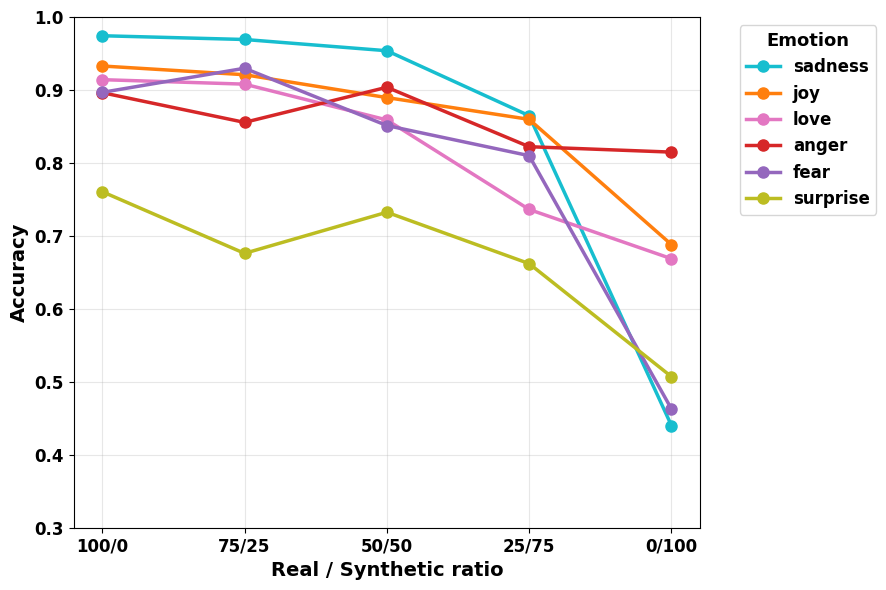

In [ ]:
# Per-emotion plot
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=plt.cm.tab10.colors)

colors = {
    "sadness": 9,
    "joy": 1,
    "love": 6,
    "anger": 3,
    "fear": 4,
    "surprise": 8
}

plt.figure(figsize=(9, 6))

for emotion in labels:
    sub = all_emotion_results[
        all_emotion_results["emotion"] == emotion
    ]

    plt.plot(
        sub["ratio"].astype(str),
        sub["accuracy"],
        marker="o",
        linestyle="-",
        linewidth=2.5,
        markersize=8,
        label=emotion,
        color=plt.cm.tab10.colors[colors[emotion]]
    )

plt.xlabel("Real / Synthetic ratio", fontsize=14, fontweight="bold")
plt.ylabel("Accuracy", fontsize=14, fontweight="bold")
plt.ylim(0.3, 1.0)

plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.grid(True, alpha=0.3)

plt.legend(
    title="Emotion",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=12,
    title_fontsize=13
)
for text in plt.gca().get_legend().get_texts():
    text.set_fontweight("semibold")

plt.gca().get_legend().get_title().set_fontweight("semibold")

plt.tight_layout()
plt.show()

In [ ]:
summary_df = (
    all_emotion_results
    .groupby("ratio")["accuracy"]
    .agg(
        mean_accuracy="mean",
        std_accuracy="std"
    )
    .reset_index()
)

ratio_order = ["100/0", "75/25", "50/50", "25/75", "0/100"]

summary_df["ratio"] = pd.Categorical(
    summary_df["ratio"],
    categories=ratio_order,
    ordered=True
)

summary_df = summary_df.sort_values("ratio")

print(summary_df)

   ratio  mean_accuracy  std_accuracy
1  100/0       0.895803      0.072335
4  75/25       0.876569      0.104884
3  50/50       0.864925      0.074554
2  25/75       0.792456      0.078901
0  0/100       0.596918      0.149402


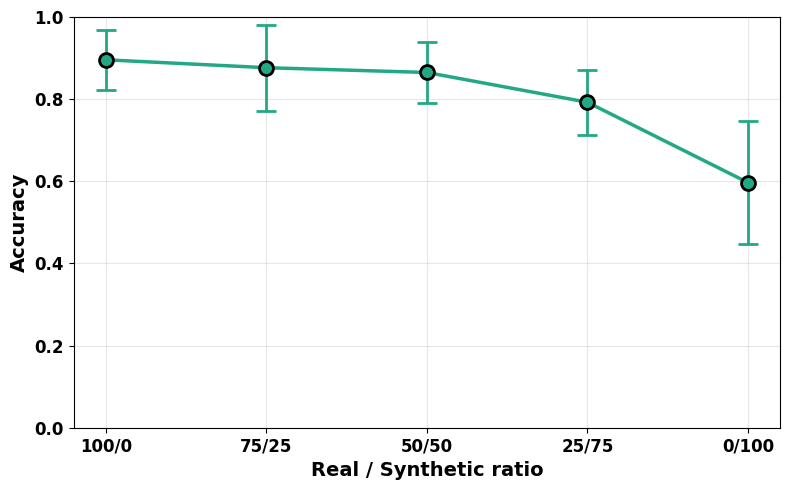

In [ ]:
# Per-ratio plot
plt.figure(figsize=(8, 5))

plt.errorbar(
    range(len(summary_df)),
    summary_df["mean_accuracy"],
    yerr=summary_df["std_accuracy"],
    fmt="o-",
    color=plt.cm.viridis(0.6),
    capsize=7,
    capthick=2,
    elinewidth=2,
    linewidth=2.5,
    markersize=10,
    markeredgewidth=2,
    markeredgecolor="black"
)

plt.xlabel("Real / Synthetic ratio", fontsize=14, fontweight="bold")
plt.ylabel("Accuracy", fontsize=14, fontweight="bold")

plt.xticks(
    range(len(ratio_order)),
    ratio_order,
    fontsize=12,
    fontweight="bold"
)

plt.yticks(fontsize=12, fontweight="bold")

plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()